# 목차

1.  Google Drive 마운트 및 데이터 압축 해제
2.  필요 라이브러리 설치
3.  데이터 로드 및 매칭 확인
4.  데이터셋 및 데이터 로더 구현
5.  ResNet+LSTM 모델 아키텍처 정의
6.  모델 학습 및 평가 루프 구현
7.  평가 결과 분석 및 모델 개선
8.  최종 결과 보고

### 1. Google Drive 마운트 및 데이터 압축 해제

Google Drive를 Colab 환경에 마운트하여 데이터셋 파일에 접근하고, 압축된 데이터셋 파일을 해제합니다.

In [ ]:
# 1. 데이터 준비 (Google Drive 마운트 및 압축 해제)
# ==================================================================
print("\n✅ 2. 데이터 준비 시작")
drive.mount('/content/drive')

# --- 경로 설정 ---
# 아래 경로들은 본인의 Google Drive 환경에 맞게 수정해주세요.
zip_file_path = '/content/drive/MyDrive/handshacke/dataset2.zip'
extract_path = '/content/handshacke_dataset2'
model_save_path = '/content/drive/MyDrive/handshacke/models' # 모델 저장 경로

# --- 디렉토리 생성 ---
os.makedirs(extract_path, exist_ok=True)
os.makedirs(model_save_path, exist_ok=True)

# --- 압축 해제 ---
if os.path.exists(zip_file_path):
    print(f"'{zip_file_path}' 압축 해제 중...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("압축 해제 완료!")
else:
    raise FileNotFoundError(f"오류: 압축 파일 '{zip_file_path}'를 찾을 수 없습니다.")

### 2. 필요 라이브러리 설치

데이터 처리, 모델 구축 및 학습에 필요한 라이브러리 (torch, torchvision, opencv-python, numpy 등)를 설치합니다. 이미 설치되어 있다면 "Requirement already satisfied" 메시지가 출력됩니다.

In [ ]:
%pip install torchvision opencv-python numpy torch

In [ ]:
# ==================================================================
# 2. 기본 설정 및 라이브러리 임포트
# ==================================================================
import os
import zipfile
import json
import numpy as np
import pickle
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.cuda.amp import GradScaler, autocast
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from google.colab import drive

print("✅ 1. 라이브러리 임포트 완료")

### 3. 데이터 로드 및 매칭 확인

압축 해제된 데이터셋 폴더에서 영상, 키포인트, 레이블 파일을 로드하고 서로 매칭하여 학습 가능한 형태로 준비합니다. 데이터 로드 및 매칭 결과를 확인합니다.

### 4. 데이터셋 및 데이터 로더 구현 (전처리)



PyTorch의 `Dataset` 및 `DataLoader` 클래스를 사용하여 로드된 데이터를 모델 학습에 적합한 형태로 변환하고 배치 단위로 제공합니다.

In [ ]:
# 3. 데이터 전처리: JSON -> NPY 변환 (가장 중요한 부분)
# ==================================================================
print("\n✅ 3. 데이터 전처리(JSON -> NPY) 시작")

# --- 경로 재설정 ---
train_keypoints_path = os.path.join(extract_path, 'Training', 'keypoint')
val_keypoints_path = os.path.join(extract_path, 'Validation', 'keypoint')
train_keypoints_npy_path = os.path.join(extract_path, 'Training', 'keypoints_npy')
val_keypoints_npy_path = os.path.join(extract_path, 'Validation', 'keypoints_npy')
os.makedirs(train_keypoints_npy_path, exist_ok=True)
os.makedirs(val_keypoints_npy_path, exist_ok=True)

KEYPOINT_DIM = 411 # 137 keypoints * 3 (x, y, confidence)

def unified_keypoint_normalization(keypoints_sequence_raw):
    """
    [수정 완료] 실시간 추론과 100% 동일한 로직을 사용하는 통합 정규화 함수.
    OpenPose JSON 출력에서 'people' 필드가 딕셔너리 형태인 것을 반영했습니다.
    """
    processed_keypoints_sequence = []
    KEYPOINT_DIM = 411 # 137 keypoints * 3 (x, y, confidence)

    for frame_data in keypoints_sequence_raw:
        # [수정 1] 'people'이 리스트가 아닌 단일 딕셔너리이므로, [0] 인덱싱을 제거하고 바로 딕셔너리를 가져옵니다.
        # .get('people', {})를 사용하여 'people' 키가 없으면 빈 딕셔너리를 반환합니다.
        person_data = frame_data.get('people', {})

        # [수정 2] 딕셔너리가 비어있는지(사람이 감지되지 않았는지) 먼저 확인합니다.
        if not person_data:
            processed_keypoints_sequence.append(np.zeros(KEYPOINT_DIM, dtype=np.float32))
            continue

        # 필수 키포인트 데이터가 없으면 빈 프레임으로 처리 (기존 로직 유지)
        if not all(k in person_data for k in ['pose_keypoints_2d', 'face_keypoints_2d', 'hand_left_keypoints_2d', 'hand_right_keypoints_2d']):
            processed_keypoints_sequence.append(np.zeros(KEYPOINT_DIM, dtype=np.float32))
            continue

        # 각 파트의 키포인트를 (N, 3) 형태로 변환
        pose = np.array(person_data.get('pose_keypoints_2d', [])).reshape(-1, 3)
        face = np.array(person_data.get('face_keypoints_2d', [])).reshape(-1, 3)
        hand_left = np.array(person_data.get('hand_left_keypoints_2d', [])).reshape(-1, 3)
        hand_right = np.array(person_data.get('hand_right_keypoints_2d', [])).reshape(-1, 3)

        # 데이터셋 표준에 따라 키포인트 결합 (Pose: 25, Face: 70, Hands: 21+21 = 137)
        if pose.shape[0] < 25 or face.shape[0] < 70 or hand_left.shape[0] < 21 or hand_right.shape[0] < 21:
            processed_keypoints_sequence.append(np.zeros(KEYPOINT_DIM, dtype=np.float32))
            continue
        keypoints_2d = np.vstack([pose[:25], face[:70], hand_left, hand_right])

        # 1. 기준점(Anchor Point) 설정: 목(Neck) 좌표 (OpenPose index: 1)
        neck_point = keypoints_2d[1, :2]
        if np.all(neck_point == 0): # 목이 감지되지 않으면 정규화 불가
            processed_keypoints_sequence.append(np.zeros(KEYPOINT_DIM, dtype=np.float32))
            continue

        # 2. 위치 정규화 (Translation Normalization): 모든 좌표를 목 기준으로 이동
        relative_keypoints = keypoints_2d[:, :2] - neck_point

        # 3. 크기 정규화 (Scale Normalization): 어깨너비로 모든 좌표를 나눔
        left_shoulder = keypoints_2d[5, :2] # OpenPose index: 5
        right_shoulder = keypoints_2d[2, :2] # OpenPose index: 2

        if np.all(left_shoulder != 0) and np.all(right_shoulder != 0):
            shoulder_dist = np.linalg.norm(left_shoulder - right_shoulder)
            if shoulder_dist > 1e-4: # 거리가 너무 작으면 나누기 오류 방지
                relative_keypoints /= shoulder_dist

        # 정규화된 (x, y) 좌표와 원본 신뢰도(confidence) 점수를 합쳐서 최종 프레임 생성
        normalized_frame = np.hstack((relative_keypoints, keypoints_2d[:, 2:3]))
        processed_keypoints_sequence.append(normalized_frame.flatten())

    return np.array(processed_keypoints_sequence, dtype=np.float32)

def convert_jsons_to_npy(keypoint_dir, npy_output_dir):
    print(f"\n'{os.path.basename(keypoint_dir)}'의 JSON 파일들을 .npy로 변환합니다.")
    keypoint_folders = [d for d in os.listdir(keypoint_dir) if os.path.isdir(os.path.join(keypoint_dir, d))]

    for folder_name in tqdm(keypoint_folders, desc="전처리 진행률"):
        folder_path = os.path.join(keypoint_dir, folder_name)
        keypoint_files = sorted([f for f in os.listdir(folder_path) if f.endswith('_keypoints.json')])

        if not keypoint_files: continue

        try:
            # 각 영상의 모든 JSON 프레임을 읽음
            keypoints_sequence_raw = [json.load(open(os.path.join(folder_path, kp_file), 'r', encoding='utf-8')) for kp_file in keypoint_files]

            # [변경점] 통합된 정규화 함수를 호출
            processed_array = unified_keypoint_normalization(keypoints_sequence_raw)

            # 정규화된 배열을 .npy 파일로 저장
            output_npy_path = os.path.join(npy_output_dir, f"{folder_name}.npy")
            np.save(output_npy_path, processed_array)
        except Exception as e:
            # 오류 발생 시 어떤 파일에서 문제가 발생했는지 출력
            print(f"\n[오류] 파일 처리 실패: {folder_name}, 메시지: {e}")
            continue

# --- 전처리 실행 ---
convert_jsons_to_npy(train_keypoints_path, train_keypoints_npy_path)
convert_jsons_to_npy(val_keypoints_path, val_keypoints_npy_path)


✅ 3. 데이터 전처리(JSON -> NPY) 시작

'keypoint'의 JSON 파일들을 .npy로 변환합니다.


전처리 진행률: 100%|██████████| 1000/1000 [00:38<00:00, 25.99it/s]



'keypoint'의 JSON 파일들을 .npy로 변환합니다.


전처리 진행률: 100%|██████████| 500/500 [00:29<00:00, 16.71it/s]


In [ ]:
# 4. 데이터 로더 준비
# ==================================================================
print("\n✅ 4. 데이터 로더 준비 시작")

# --- 경로 설정 ---
train_labels_path = os.path.join(extract_path, 'Training', 'labels')
val_labels_path = os.path.join(extract_path, 'Validation', 'labels')

def load_data_paths(keypoint_npy_dir, label_dir):
    """라벨 파일을 기준으로 유효한 .npy 파일 경로와 라벨을 매칭합니다."""
    data_list = []
    label_files = [f for f in os.listdir(label_dir) if f.endswith('_morpheme.json')]

    for label_filename in tqdm(label_files, desc=f"{os.path.basename(label_dir)} 데이터 매칭"):
        base_name = label_filename.replace('_morpheme.json', '')
        keypoint_path = os.path.join(keypoint_npy_dir, f"{base_name}.npy")

        if os.path.exists(keypoint_path):
            try:
                with open(os.path.join(label_dir, label_filename), 'r', encoding='utf-8') as f:
                    label_data = json.load(f)
                sign_word = label_data['data'][0]['attributes'][0]['name']
                data_list.append({'keypoint_path': keypoint_path, 'label': sign_word})
            except Exception:
                continue
    return data_list

# --- 데이터 경로 리스트 생성 ---
final_train_data = load_data_paths(train_keypoints_npy_path, train_labels_path)
final_val_data = load_data_paths(val_keypoints_npy_path, val_labels_path)

# --- 통합 라벨 맵 생성 ---
all_labels = [item['label'] for item in final_train_data] + [item['label'] for item in final_val_data]
unique_labels = sorted(list(set(all_labels)))
global_label_map = {label: i for i, label in enumerate(unique_labels)}
num_classes = len(global_label_map)

# 라벨 맵 저장 (나중에 추론 시 필요)
label_map_path = os.path.join(model_save_path, 'label_map.json')
with open(label_map_path, 'w', encoding='utf-8') as f:
    json.dump(global_label_map, f, ensure_ascii=False, indent=4)
print(f"라벨 맵 저장 완료: {label_map_path}")

# --- PyTorch Dataset 클래스 정의 ---
class KeypointDataset(Dataset):
    def __init__(self, data_list, label_map, sequence_length=150, is_train=False):
        self.data_list = data_list
        self.label_map = label_map
        self.sequence_length = sequence_length
        self.is_train = is_train
        self.keypoint_dim = KEYPOINT_DIM

    def __len__(self):
        return len(self.data_list)

    def _augment_keypoints(self, keypoints):
        noise = np.random.normal(0, 0.01, keypoints.shape)
        scale_factor = np.random.uniform(0.9, 1.1)
        return (keypoints + noise) * scale_factor

    def __getitem__(self, idx):
        item = self.data_list[idx]
        # .npy 파일은 이미 정규화가 완료된 상태이므로 바로 로드
        keypoints_array = np.load(item['keypoint_path'])

        if self.is_train:
            keypoints_array = self._augment_keypoints(keypoints_array)

        keypoints_final = self._pad_or_trim_sequence(keypoints_array)
        label_id = self.label_map[item['label']]

        return torch.tensor(keypoints_final, dtype=torch.float32), label_id

    def _pad_or_trim_sequence(self, seq):
        current_len = len(seq)
        target_len = self.sequence_length
        if current_len == target_len:
            return seq
        if current_len > target_len:
            return seq[:target_len]
        else: # current_len < target_len
            pad_shape = (target_len - current_len, self.keypoint_dim)
            return np.vstack([seq, np.zeros(pad_shape, dtype=np.float32)])


✅ 4. 데이터 로더 준비 시작


labels 데이터 매칭:   0%|          | 0/1000 [00:00<?, ?it/s]

labels 데이터 매칭:   0%|          | 0/500 [00:00<?, ?it/s]

라벨 맵 저장 완료: /content/drive/MyDrive/handshacke/models/label_map.json


### 5. LSTM 모델 아키텍처 정의

비디오 프레임에서 특징을 추출하는 ResNet과 시퀀스 데이터를 처리하는 LSTM을 결합한 모델 아키텍처를 정의합니다. 이 모델은 최종적으로 수어 단어를 분류하는 역할을 수행합니다.

In [ ]:
# 5. 모델 아키텍처 정의
# ==================================================================
print("\n✅ 5. 모델 아키텍처 정의 시작")

class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, lstm_outputs):
        scores = self.attention(lstm_outputs).squeeze(2)
        weights = F.softmax(scores, dim=1)
        return torch.bmm(weights.unsqueeze(1), lstm_outputs).squeeze(1)

class KeypointLSTM_Attention(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size=256, num_layers=2, dropout=0.5):
        super(KeypointLSTM_Attention, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.attention = Attention(hidden_size * 2) # 양방향이므로 2배
        self.fc = nn.Linear(hidden_size * 2, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        context_vector = self.attention(lstm_out)
        return self.fc(self.dropout(context_vector))


✅ 5. 모델 아키텍처 정의 시작


### 6. 모델 학습 및 평가 루프 구현

모델 학습에 필요한 손실 함수(Loss Function)와 옵티마이저(Optimizer)를 설정하고, 훈련 데이터셋과 검증 데이터셋을 사용하여 모델을 학습하고 평가하는 루프를 구현합니다.

In [ ]:
# 6. 학습 및 평가 함수 정의
# ==================================================================
print("\n✅ 6. 학습 및 평가 함수 정의 시작")

def train_one_epoch(model, dataloader, criterion, optimizer, scaler, device):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0

    for kpts, labels in tqdm(dataloader, desc="Training", leave=False):
        kpts, labels = kpts.to(device), labels.to(device)
        optimizer.zero_grad()

        with autocast(enabled=(device.type == 'cuda')):
            outputs = model(kpts)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * kpts.size(0)
        total_correct += (outputs.argmax(1) == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples

def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0

    with torch.no_grad():
        for kpts, labels in tqdm(dataloader, desc="Evaluating", leave=False):
            kpts, labels = kpts.to(device), labels.to(device)
            with autocast(enabled=(device.type == 'cuda')):
                outputs = model(kpts)
                loss = criterion(outputs, labels)

            total_loss += loss.item() * kpts.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples

def plot_history(history):
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_acc'], 'b-', label='Train Accuracy')
    plt.plot(history['val_acc'], 'r-', label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_loss'], 'b-', label='Train Loss')
    plt.plot(history['val_loss'], 'r-', label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


✅ 6. 학습 및 평가 함수 정의 시작


### 7. 평가 결과 분석 및 모델 개선

학습 과정에서 기록된 훈련 손실, 검증 손실, 정확도 등의 지표를 시각화하고 분석하여 모델의 성능을 평가합니다. 필요에 따라 모델 구조 수정, 하이퍼파라미터 튜닝 또는 데이터 증강 기법 적용 등을 통해 모델 성능을 개선합니다.

*(이 섹션의 코드는 학습 결과 분석 및 시각화, 모델 개선 방향 제시에 초점을 맞춥니다. 실제 모델 개선 작업은 분석 결과에 따라 추가적인 코드가 필요할 수 있습니다.)*


✅ 7. 최종 학습 실행 시작
사용 장치: cuda
총 클래스 수: 113, 훈련 데이터: 1000, 검증 데이터: 500


/tmp/ipython-input-2488985059.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))


Training:   0%|          | 0/16 [00:00<?, ?it/s]

/tmp/ipython-input-1566961715.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):


Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 104/300 [2.67s] | Train Acc: 0.9920, Val Acc: 0.7740 | Train Loss: 0.1311, Val Loss: 0.9090


Training:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 105/300 [2.51s] | Train Acc: 0.9890, Val Acc: 0.7860 | Train Loss: 0.1333, Val Loss: 0.9049

조기 종료: 15 에포크 동안 검증 손실 개선이 없어 학습을 중단합니다.

--- 학습 완료 및 결과 시각화 ---


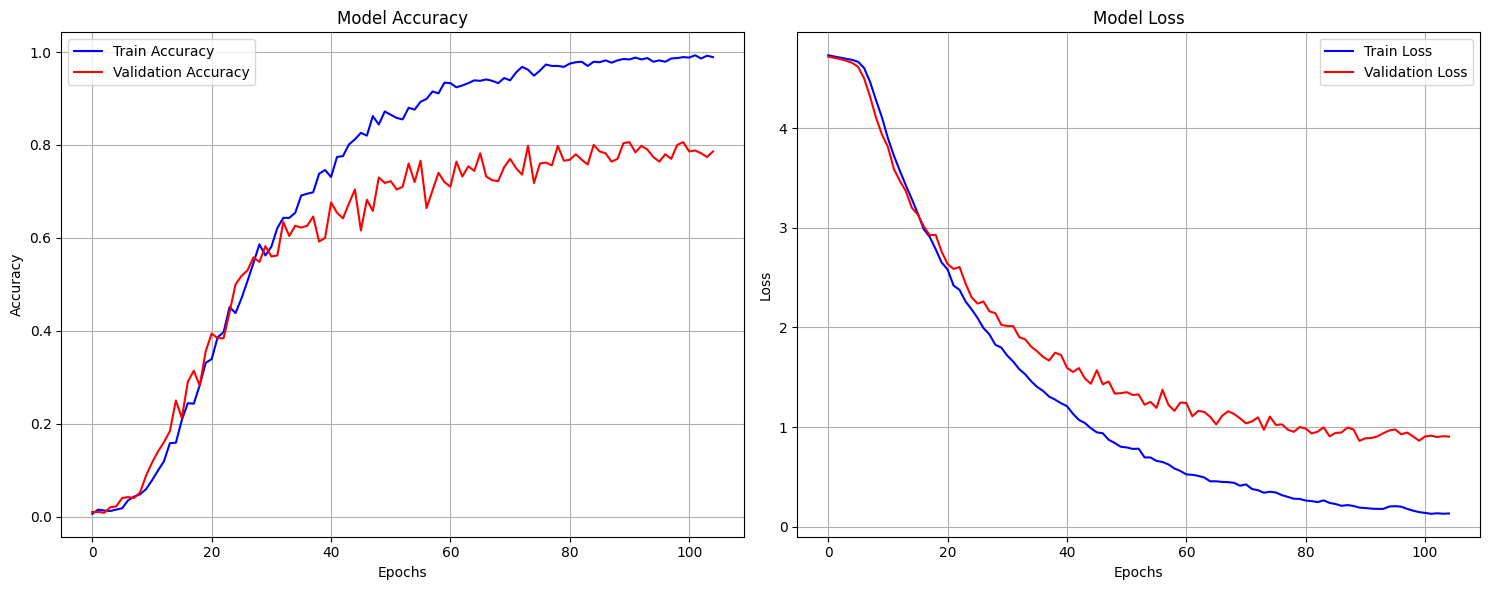

In [ ]:
# 7. 학습 실행
# ==================================================================
print("\n✅ 7. 최종 학습 실행 시작")

# --- 하이퍼파라미터 설정 ---
SEQUENCE_LENGTH = 150
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
NUM_EPOCHS = 300 # 필요 시 조절
EARLY_STOPPING_PATIENCE = 15
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- 데이터 로더 생성 ---
train_dataset = KeypointDataset(final_train_data, global_label_map, sequence_length=SEQUENCE_LENGTH, is_train=True)
val_dataset = KeypointDataset(final_val_data, global_label_map, sequence_length=SEQUENCE_LENGTH, is_train=False)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"사용 장치: {DEVICE}")
print(f"총 클래스 수: {num_classes}, 훈련 데이터: {len(train_dataset)}, 검증 데이터: {len(val_dataset)}")

# --- 모델, 옵티마이저, 손실 함수 등 초기화 ---
model = KeypointLSTM_Attention(num_classes, input_size=KEYPOINT_DIM).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()
scheduler = ReduceLROnPlateau(optimizer, 'min', patience=7, factor=0.5, verbose=True)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

# --- 학습 루프 ---
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_dataloader, criterion, optimizer, scaler, DEVICE)
    val_loss, val_acc = evaluate_model(model, val_dataloader, criterion, DEVICE)

    elapsed_time = time.time() - start_time

    print(f"Epoch {epoch+1:03d}/{NUM_EPOCHS} [{elapsed_time:.2f}s] | "
          f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f} | "
          f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_path = os.path.join(model_save_path, 'best_model.pth')
        torch.save(model.state_dict(), best_model_path)
        print(f"  -> Val Loss 개선 ({best_val_loss:.4f}). 모델 저장: {best_model_path}")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"\n조기 종료: {EARLY_STOPPING_PATIENCE} 에포크 동안 검증 손실 개선이 없어 학습을 중단합니다.")
        break

print("\n--- 학습 완료 및 결과 시각화 ---")
plot_history(history)

### 8. 최종 결과 보고

모델 학습 및 평가 결과를 종합하여 최종 보고서를 작성합니다. 여기에는 사용된 데이터셋, 모델 아키텍처, 학습 과정, 최종 성능 지표(손실, 정확도 등), 분석 결과 및 개선 방향 등이 포함될 수 있습니다.

*(이 섹션은 주로 분석 결과를 요약하고 보고하는 마크다운 셀로 구성됩니다. 필요에 따라 추가적인 시각화나 표를 포함할 수 있습니다.)*